<a href="https://colab.research.google.com/github/MalshanRuchira/NorthStar-Analytics-Project/blob/main/NorthStar_Main_Analysis_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("ggplot2", quiet=TRUE)
install.packages("dplyr", quiet=TRUE)
install.packages("scales", quiet=TRUE)

library(ggplot2)
library(dplyr)
library(scales)

orders <- read.csv("https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/orders.csv")
deliveries <- read.csv("https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/deliveries.csv")
vehicles <- read.csv("https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/vehicles.csv")
hubs <- read.csv("https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/hubs.csv")
complaints <- read.csv("https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/complaints.csv")
drivers <- read.csv("https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/drivers.csv")



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Environment Ready for R Analytics"


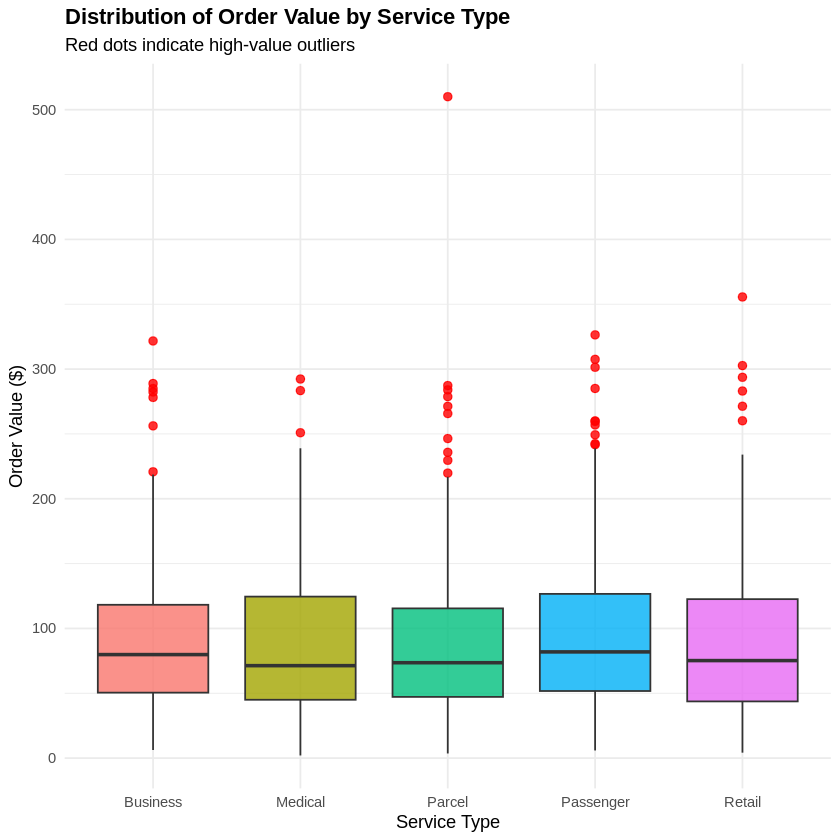

In [2]:
ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot(alpha = 0.8, outlier.color = "red", outlier.size = 2) +
  theme_minimal() +
  labs(title = "Distribution of Order Value by Service Type",
       subtitle = "Red dots indicate high-value outliers",
       x = "Service Type", y = "Order Value ($)") +
  theme(legend.position = "none", plot.title = element_text(face="bold"))

`geom_smooth()` using formula = 'y ~ x'


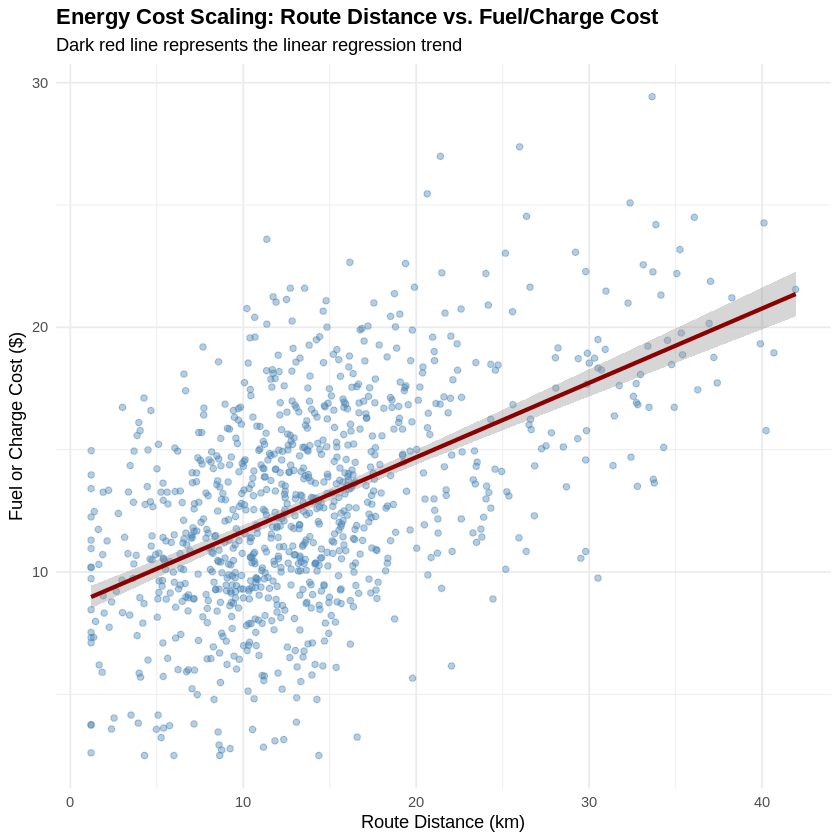

In [3]:
ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.4, color = "steelblue") +
  geom_smooth(method = "lm", color = "darkred", linewidth = 1.2) +
  theme_minimal() +
  labs(title = "Energy Cost Scaling: Route Distance vs. Fuel/Charge Cost",
       subtitle = "Dark red line represents the linear regression trend",
       x = "Route Distance (km)", y = "Fuel or Charge Cost ($)") +
  theme(plot.title = element_text(face="bold"))

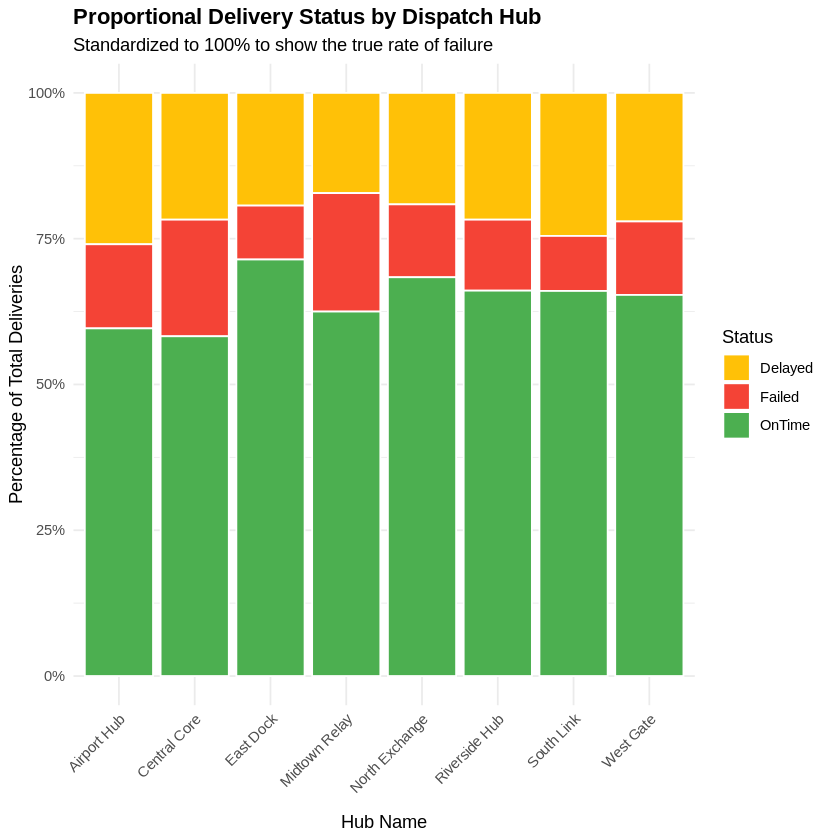

In [4]:
df_hub_del <- merge(deliveries, hubs, by = "hub_id")

ggplot(df_hub_del, aes(x = hub_name, fill = delivery_status)) +
  geom_bar(position = "fill", color="white") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("OnTime" = "#4CAF50", "Delayed" = "#FFC107", "Failed" = "#F44336")) +
  theme_minimal() +
  labs(title = "Proportional Delivery Status by Dispatch Hub",
       subtitle = "Standardized to 100% to show the true rate of failure",
       x = "Hub Name", y = "Percentage of Total Deliveries", fill = "Status") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), plot.title = element_text(face="bold"))

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_density()`).”


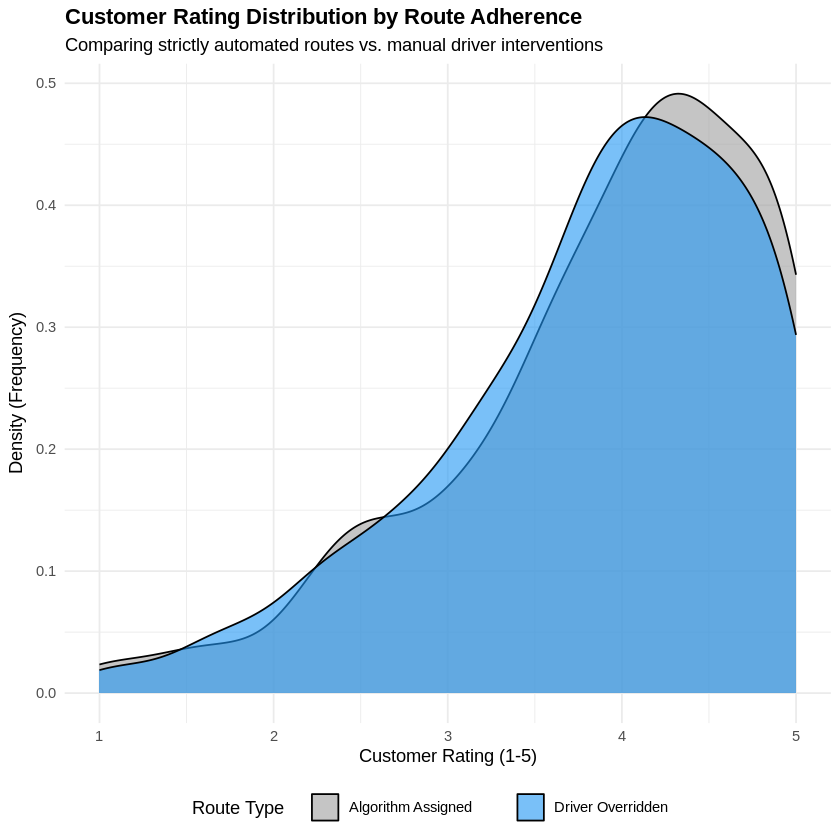

In [5]:
deliveries_mod <- deliveries %>%
  mutate(override_status = ifelse(manual_route_override_count > 0, "Driver Overridden", "Algorithm Assigned"))

ggplot(deliveries_mod, aes(x = customer_rating_post_delivery, fill = override_status)) +
  geom_density(alpha = 0.6) +
  scale_fill_manual(values = c("Driver Overridden" = "#2196F3", "Algorithm Assigned" = "#9E9E9E")) +
  theme_minimal() +
  labs(title = "Customer Rating Distribution by Route Adherence",
       subtitle = "Comparing strictly automated routes vs. manual driver interventions",
       x = "Customer Rating (1-5)", y = "Density (Frequency)", fill = "Route Type") +
  theme(plot.title = element_text(face="bold"), legend.position = "bottom")

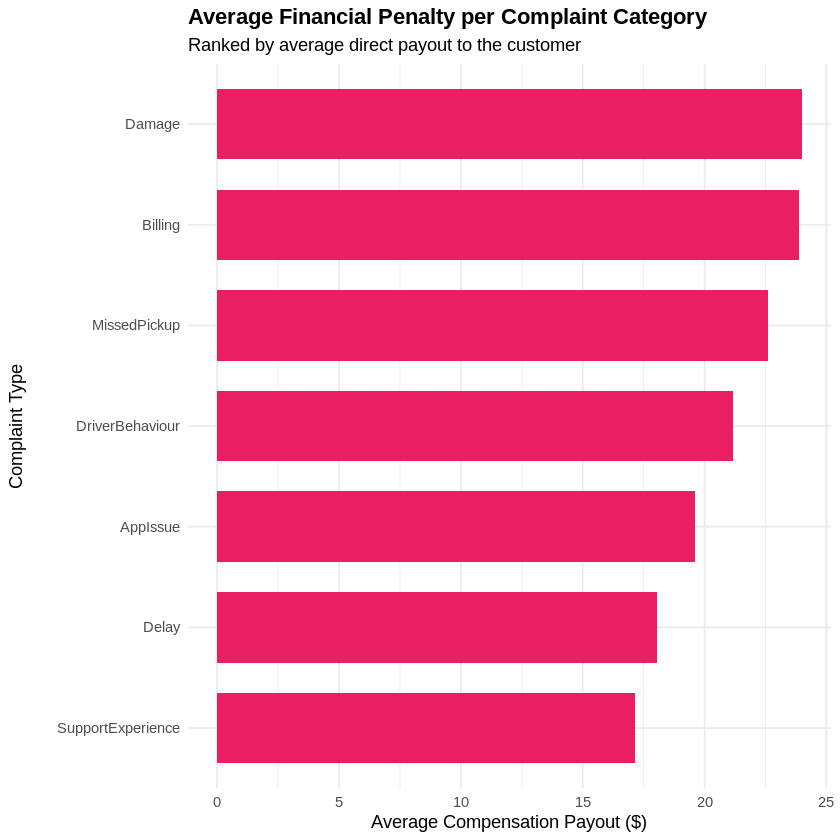

In [6]:
comp_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(avg_comp = mean(compensation_amount, na.rm=TRUE)) %>%
  arrange(desc(avg_comp))

ggplot(comp_summary, aes(x = reorder(complaint_type, avg_comp), y = avg_comp)) +
  geom_col(fill = "#E91E63", width = 0.7) +
  coord_flip() +
  theme_minimal() +
  labs(title = "Average Financial Penalty per Complaint Category",
       subtitle = "Ranked by average direct payout to the customer",
       x = "Complaint Type", y = "Average Compensation Payout ($)") +
  theme(plot.title = element_text(face="bold"))